# Análise local de longevidade

Este notebook lê as planilhas registradas em data/metadata.csv, calcula indicadores de tábuas de vida de período e gera figuras em padrão de relatório.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config.settings import K_MAX
from src.data.loaders import load_life_tables_from_metadata, load_metadata
from src.analysis.hazard import add_survival_hazard
from src.analysis.indicators import (
    age_band_hazard_contributions,
    build_indicators,
    build_milestone_long,
    conditional_survival_probabilities,
    sex_indicator_gaps,
)
from src.visualization.plots import (
    plot_age_band_hazard_contributions,
    plot_benchmark_hazard_gap_vs_chile,
    plot_conditional_survival,
    plot_hazard_curves,
    plot_indicator_bars_brazil_regions,
    plot_regional_hazard_by_sex,
    plot_regional_survival_by_sex,
    plot_sex_hazard_gap_by_region,
    plot_sex_indicator_gaps,
    plot_survival_curves,
)


## Planilhas registradas


In [2]:
metadata = load_metadata()
metadata

,filename,country,year,sex,label
0,female_life_table_northeast_brazil_2025.xlsx,Northeast Brazil,2025,Female,Northeast Brazil - Female
1,female_life_table_chile_2023.xlsx,Chile,2023,Female,Chile - Female
2,male_life_table_northeast_brazil_2025.xlsx,Northeast Brazil,2025,Male,Northeast Brazil - Male
3,male_life_table_chile_2023.xlsx,Chile,2023,Male,Chile - Male
4,female_life_table_north_brazil_2025.xlsx,North Brazil,2025,Female,North Brazil - Female
5,male_life_table_north_brazil_2025.xlsx,North Brazil,2025,Male,North Brazil - Male
6,female_life_table_southeast_brazil_2025.xlsx,Southeast Brazil,2025,Female,Southeast Brazil - Female
7,male_life_table_southeast_brazil_2025.xlsx,Southeast Brazil,2025,Male,Southeast Brazil - Male
8,female_life_table_south_brazil_2025.xlsx,South Brazil,2025,Female,South Brazil - Female
9,male_life_table_south_brazil_2025.xlsx,South Brazil,2025,Male,South Brazil - Male


## Indicadores


In [3]:
raw = load_life_tables_from_metadata()
life_tables = add_survival_hazard(raw)
indicators = build_indicators(life_tables, k_max=K_MAX)
milestones = build_milestone_long(life_tables, k_max=K_MAX)

indicators

,country,year,age_min,age_max,H_max,H_60,H_70,H_80,H_90,e0_approx,...,modal_age,median_age,x_H1,x_H2,x_H3,x_H4,x_H5,x_H6,x_H7,x_H8
0,Central-West Brazil - Female,2025,0.0,90.0,1.323880,0.098530,0.201252,0.464224,1.323880,78.634035,...,87.5,83.911995,87.090024,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Central-West Brazil - Male,2025,0.0,90.0,1.849079,0.194761,0.375632,0.770761,1.849079,72.991307,...,87.5,78.541433,82.895593,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Chile - Female,2023,0.0,90.0,1.071908,0.064922,0.148925,0.375851,1.071908,81.042863,...,87.5,85.688245,89.159684,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Chile - Male,2023,0.0,90.0,1.367944,0.110327,0.239530,0.548971,1.367944,77.750274,...,82.5,82.361327,86.202682,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,North Brazil - Female,2025,0.0,90.0,1.374586,0.105360,0.210844,0.483792,1.374586,78.080294,...,87.5,83.492009,86.745260,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,North Brazil - Male,2025,0.0,90.0,1.853139,0.208960,0.380264,0.772962,1.853139,72.280232,...,87.5,78.496718,82.902316,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Northeast Brazil - Female,2025,0.0,90.0,1.330084,0.104435,0.208108,0.467868,1.330084,78.416875,...,87.5,83.880125,87.059204,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Northeast Brazil - Male,2025,0.0,90.0,1.845215,0.226562,0.405321,0.785781,1.845215,71.936850,...,87.5,78.174673,82.827433,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,South Brazil - Female,2025,0.0,90.0,1.316581,0.093165,0.194639,0.455279,1.316581,79.045704,...,87.5,84.002048,87.143405,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,South Brazil - Male,2025,0.0,90.0,1.862326,0.180408,0.362207,0.771794,1.862326,73.603532,...,82.5,78.561070,82.754600,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Visão geral


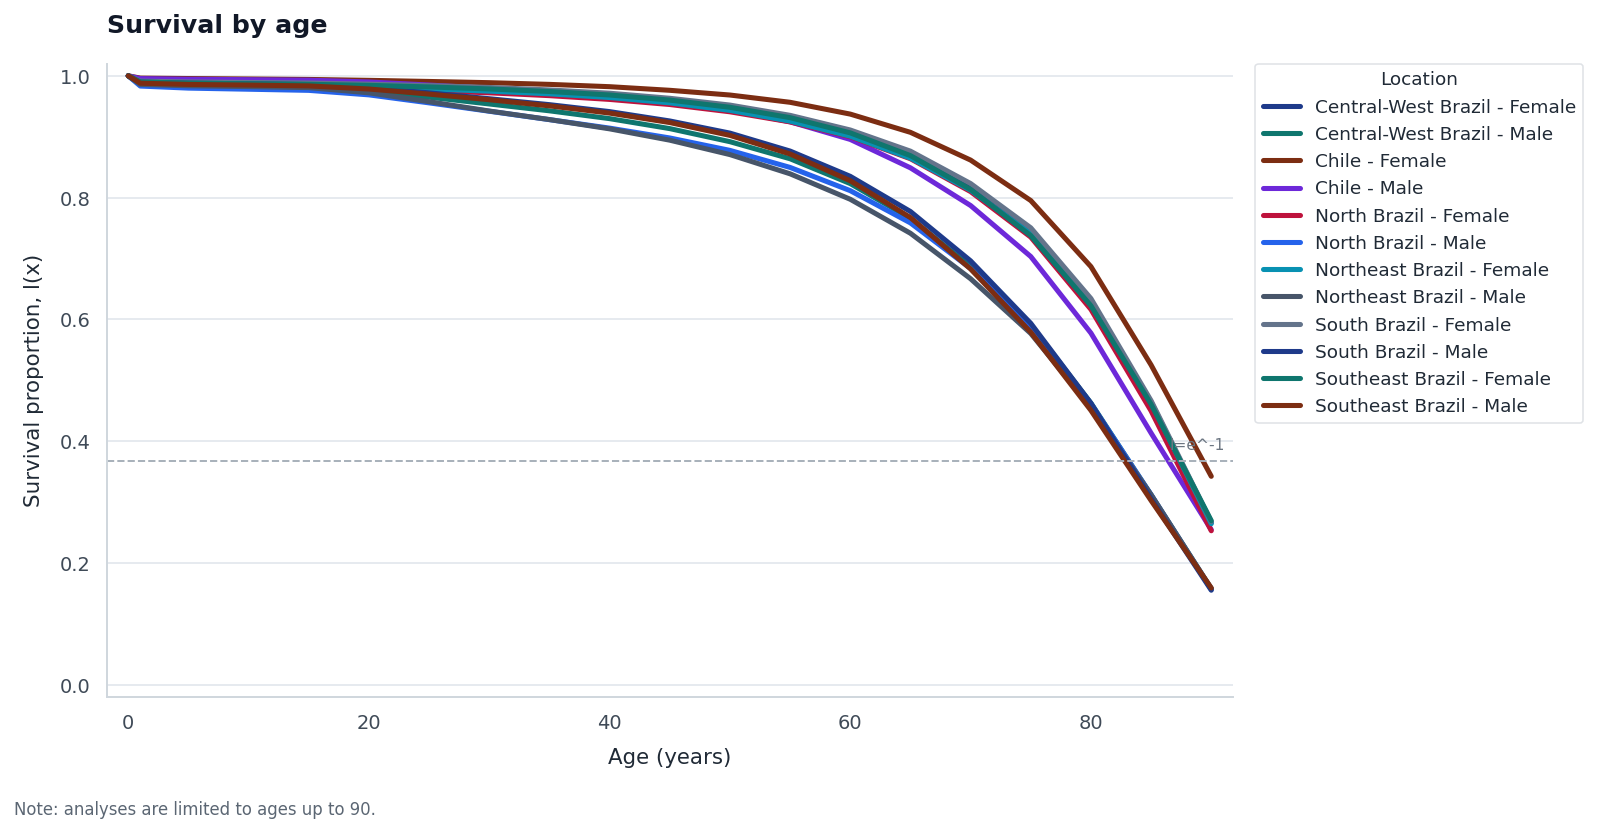

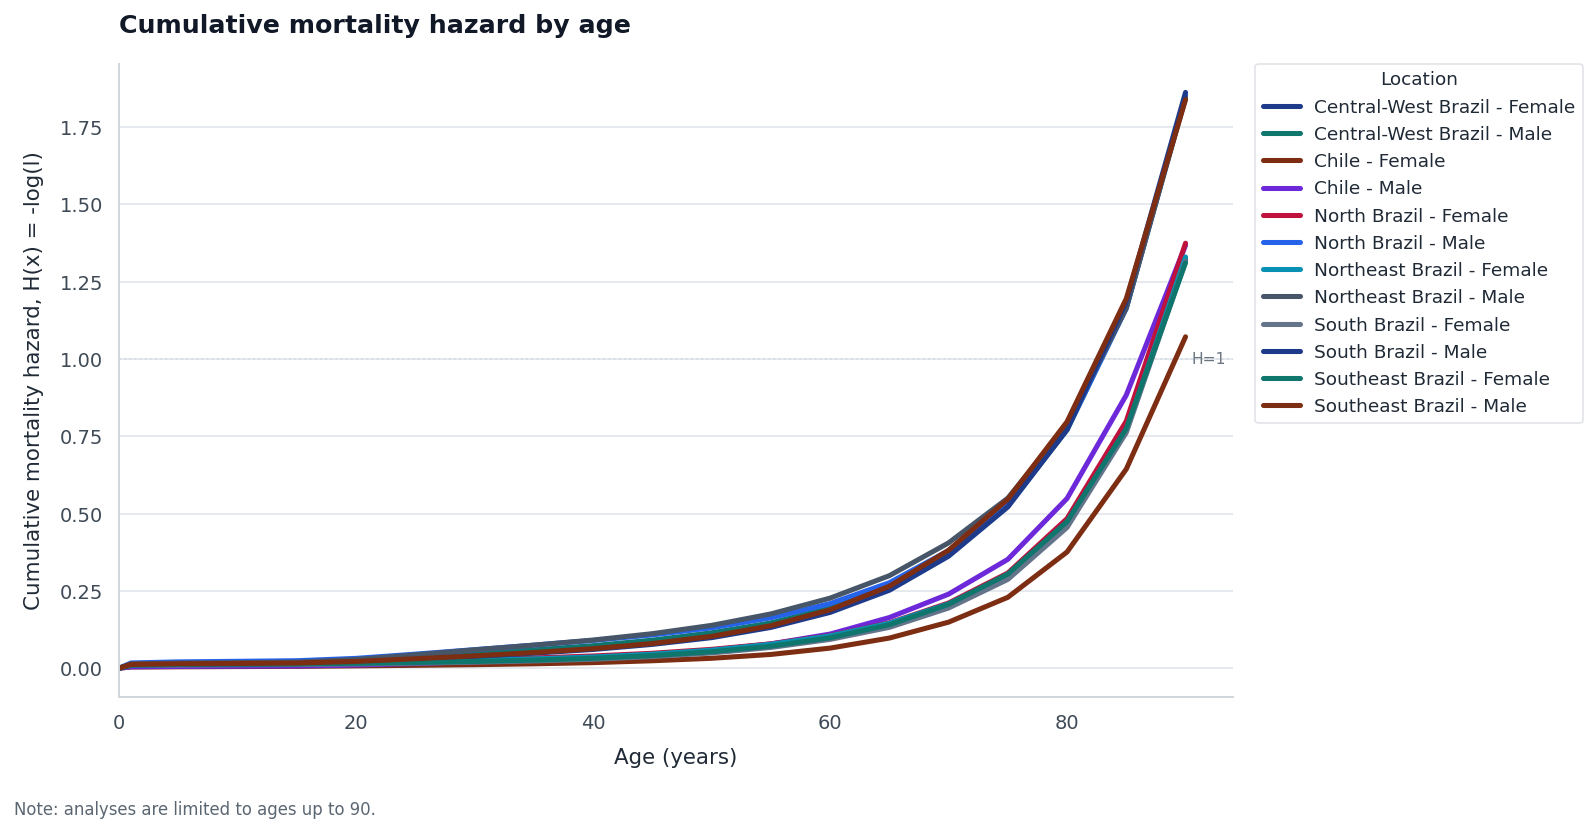

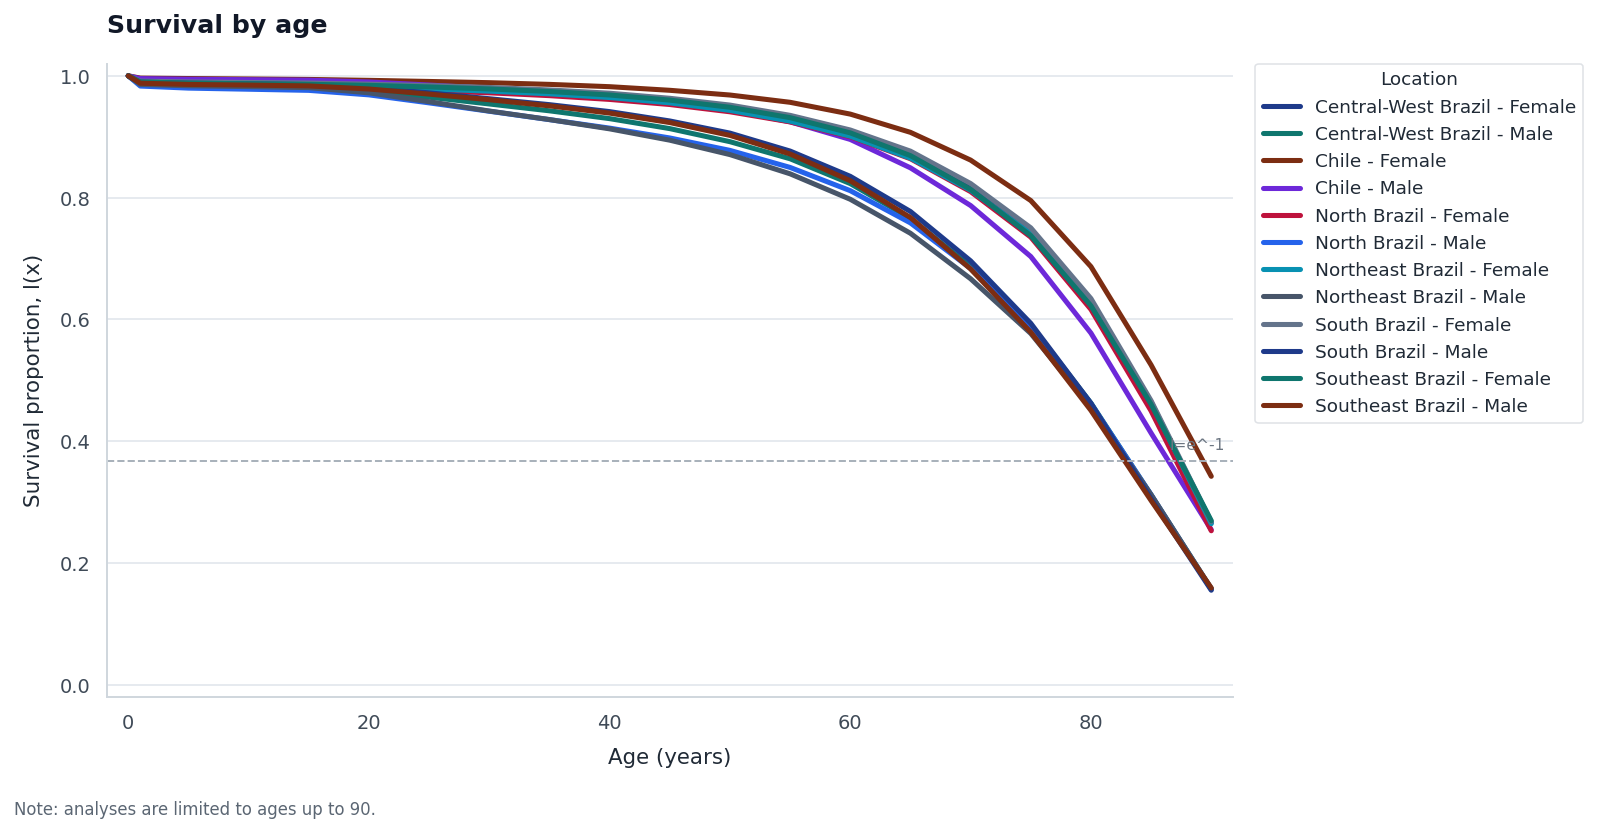

In [4]:
plot_hazard_curves(
    life_tables,
    output_path=PROJECT_ROOT / "outputs" / "figures" / "hazard_curves_all.png",
)
plot_survival_curves(
    life_tables,
    output_path=PROJECT_ROOT / "outputs" / "figures" / "survival_curves_all.png",
)


## Regiões brasileiras por sexo

Comparação direta das cinco regiões brasileiras adicionadas ao catálogo, separando mulheres e homens.


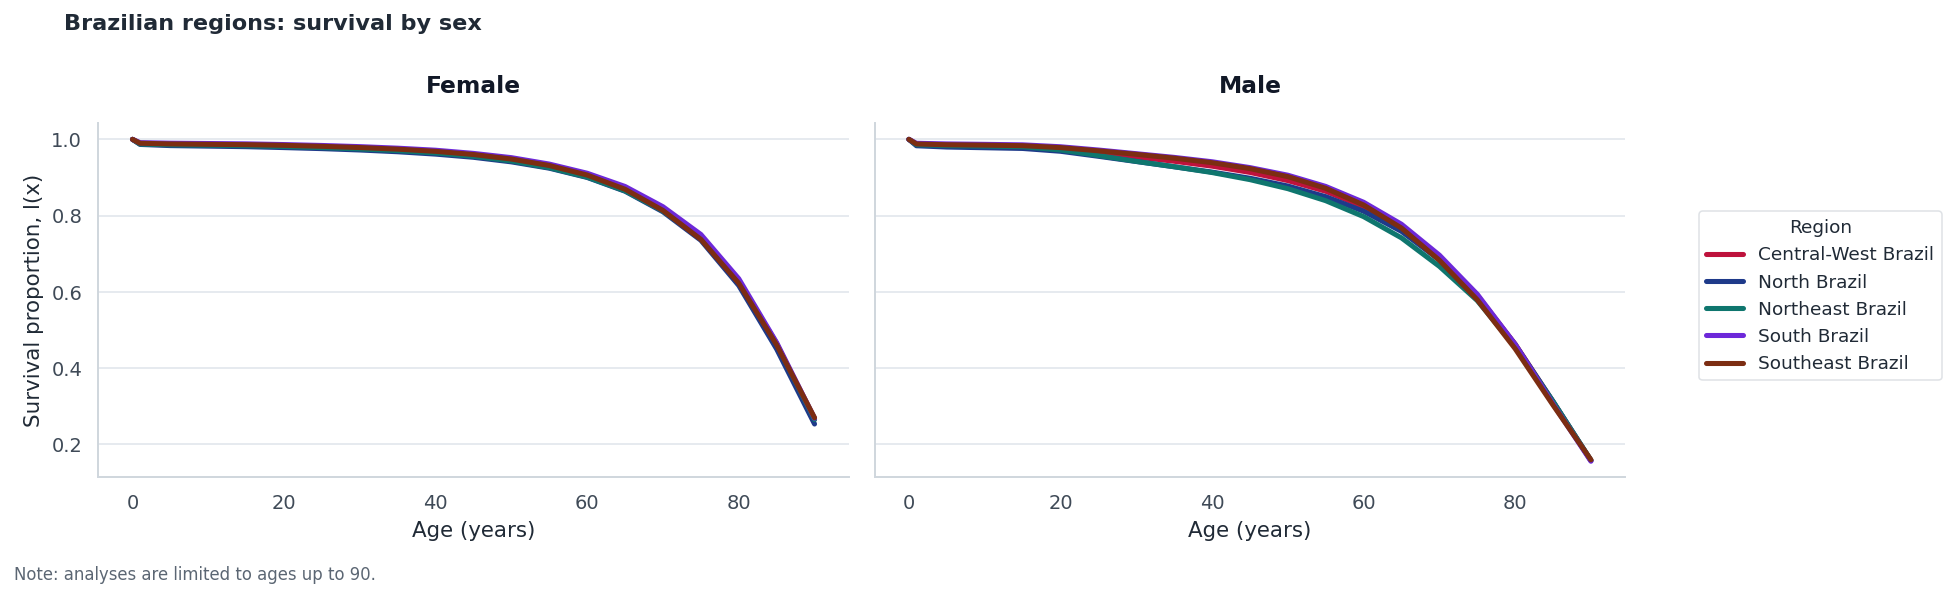

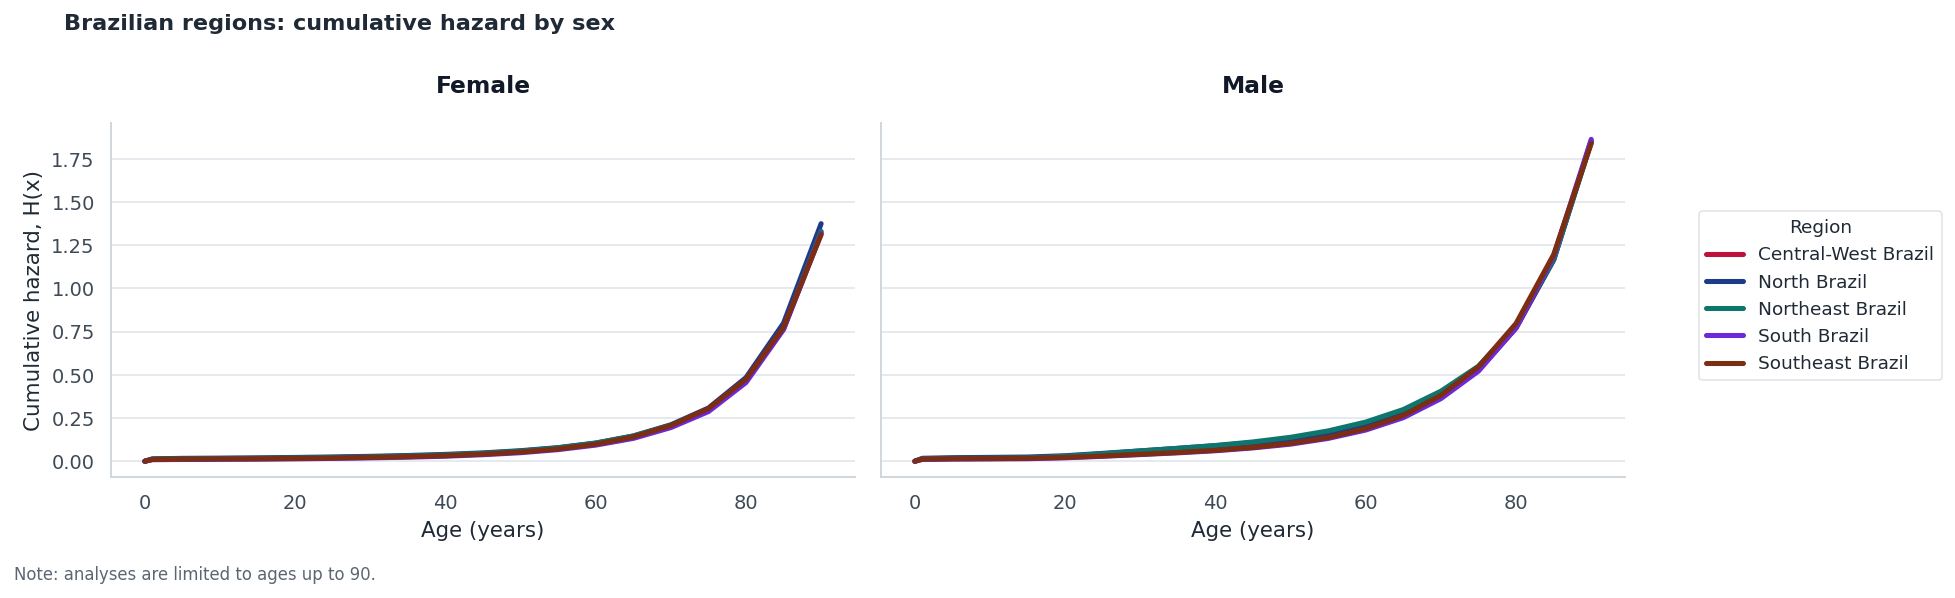

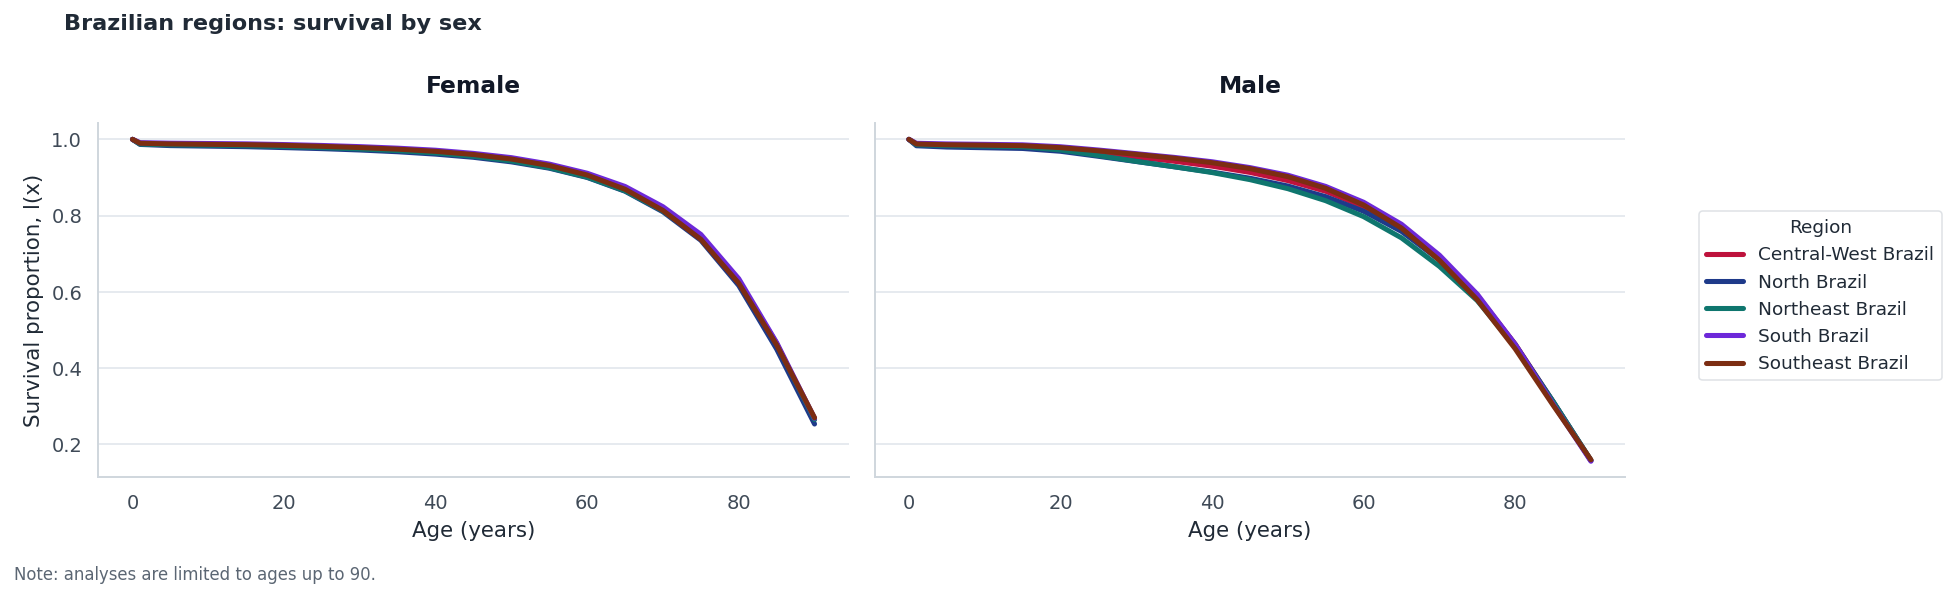

In [5]:
plot_regional_hazard_by_sex(
    life_tables,
    output_path=PROJECT_ROOT / "outputs" / "figures" / "brazil_regions_hazard_by_sex.png",
)
plot_regional_survival_by_sex(
    life_tables,
    output_path=PROJECT_ROOT / "outputs" / "figures" / "brazil_regions_survival_by_sex.png",
)


## Indicadores regionais

Resumo visual dos indicadores sintéticos por região e sexo para apoiar a seleção dos achados do relatório.


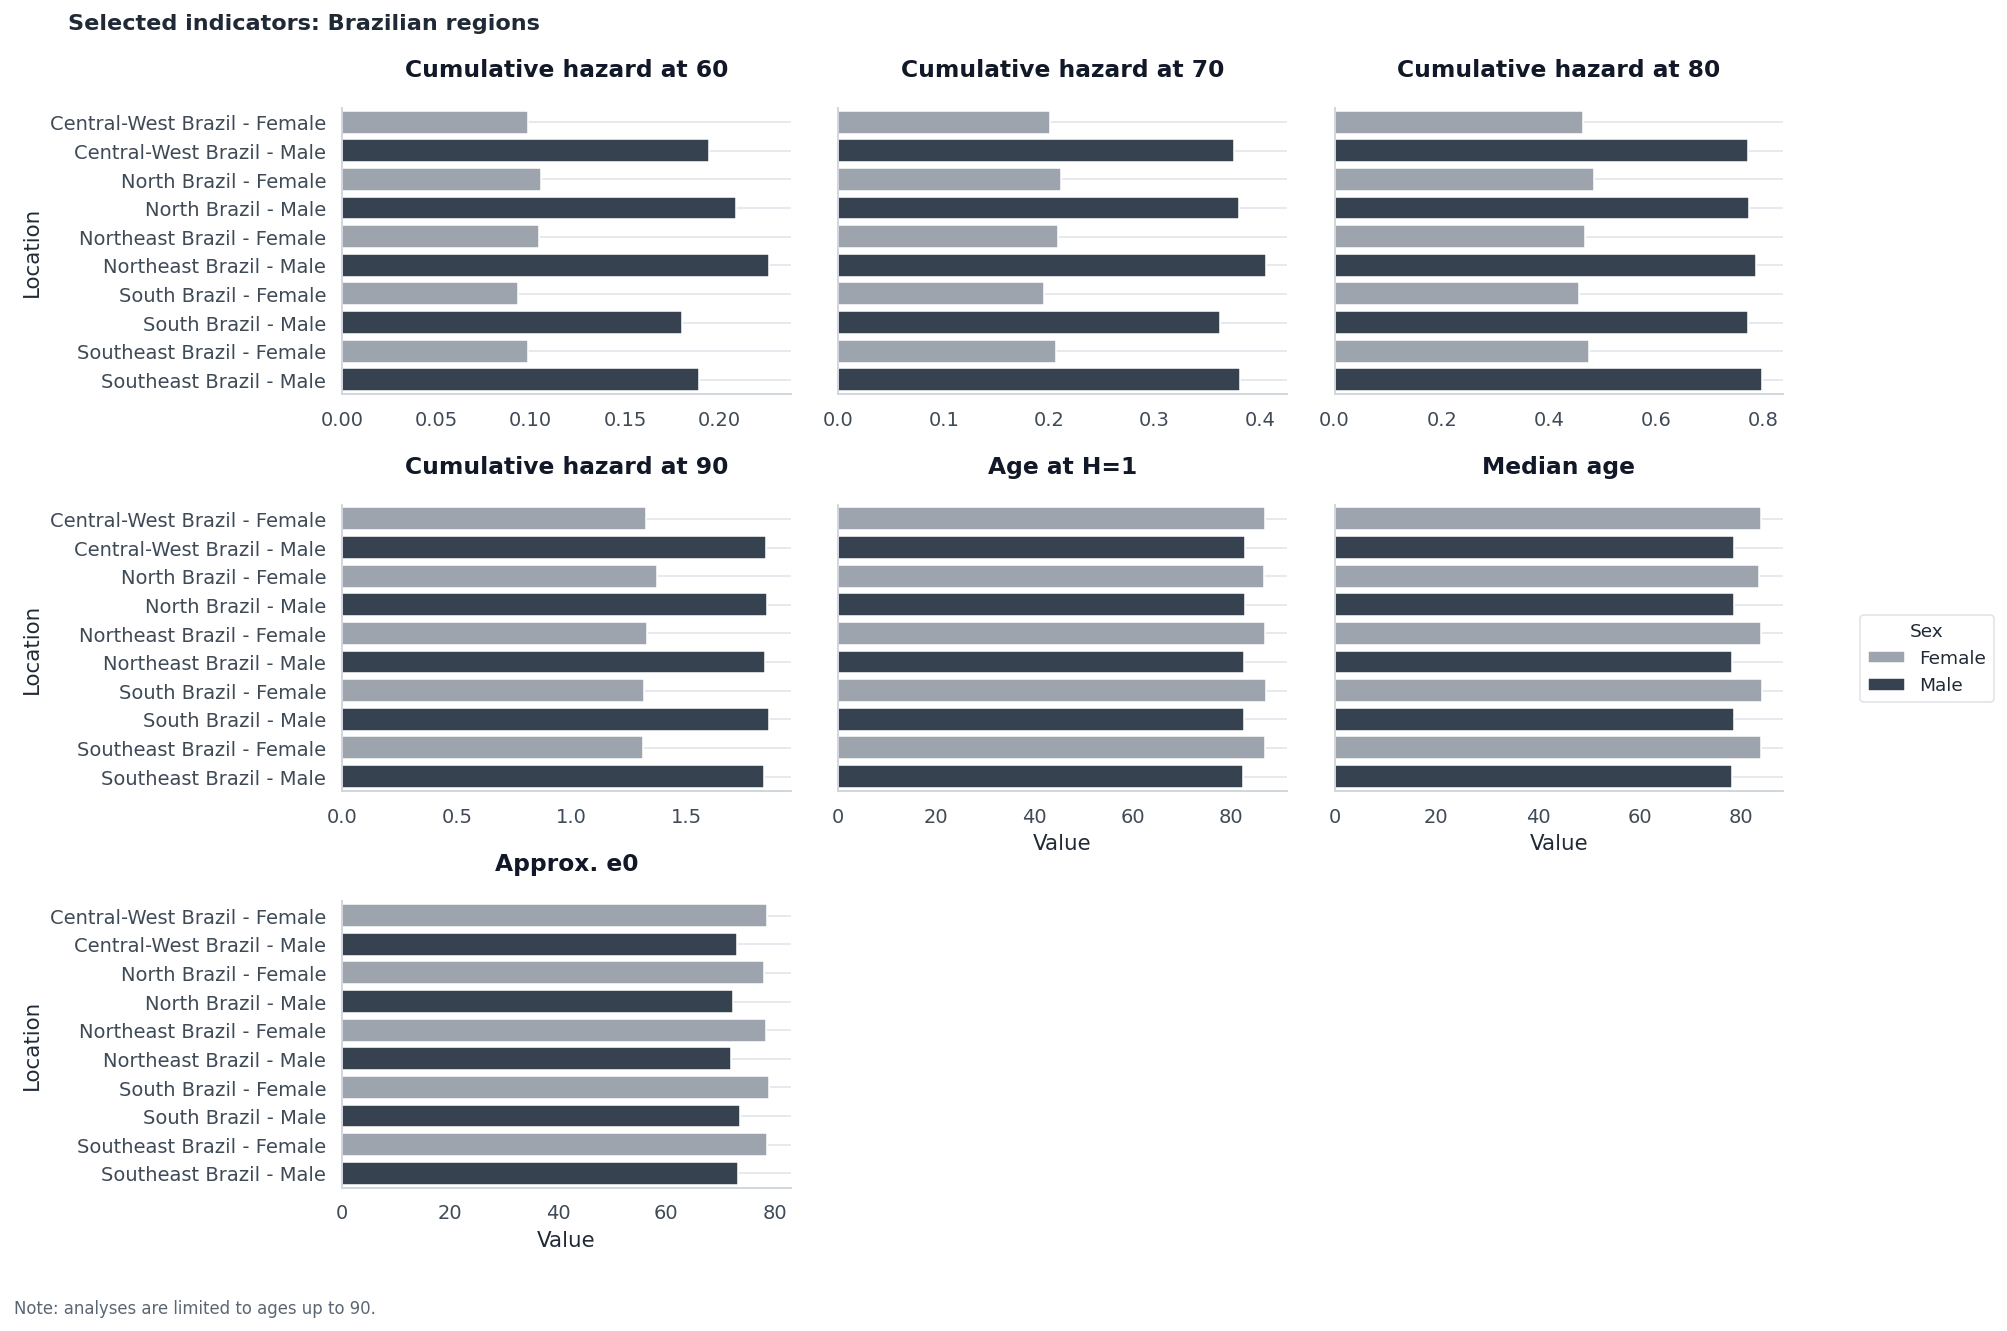

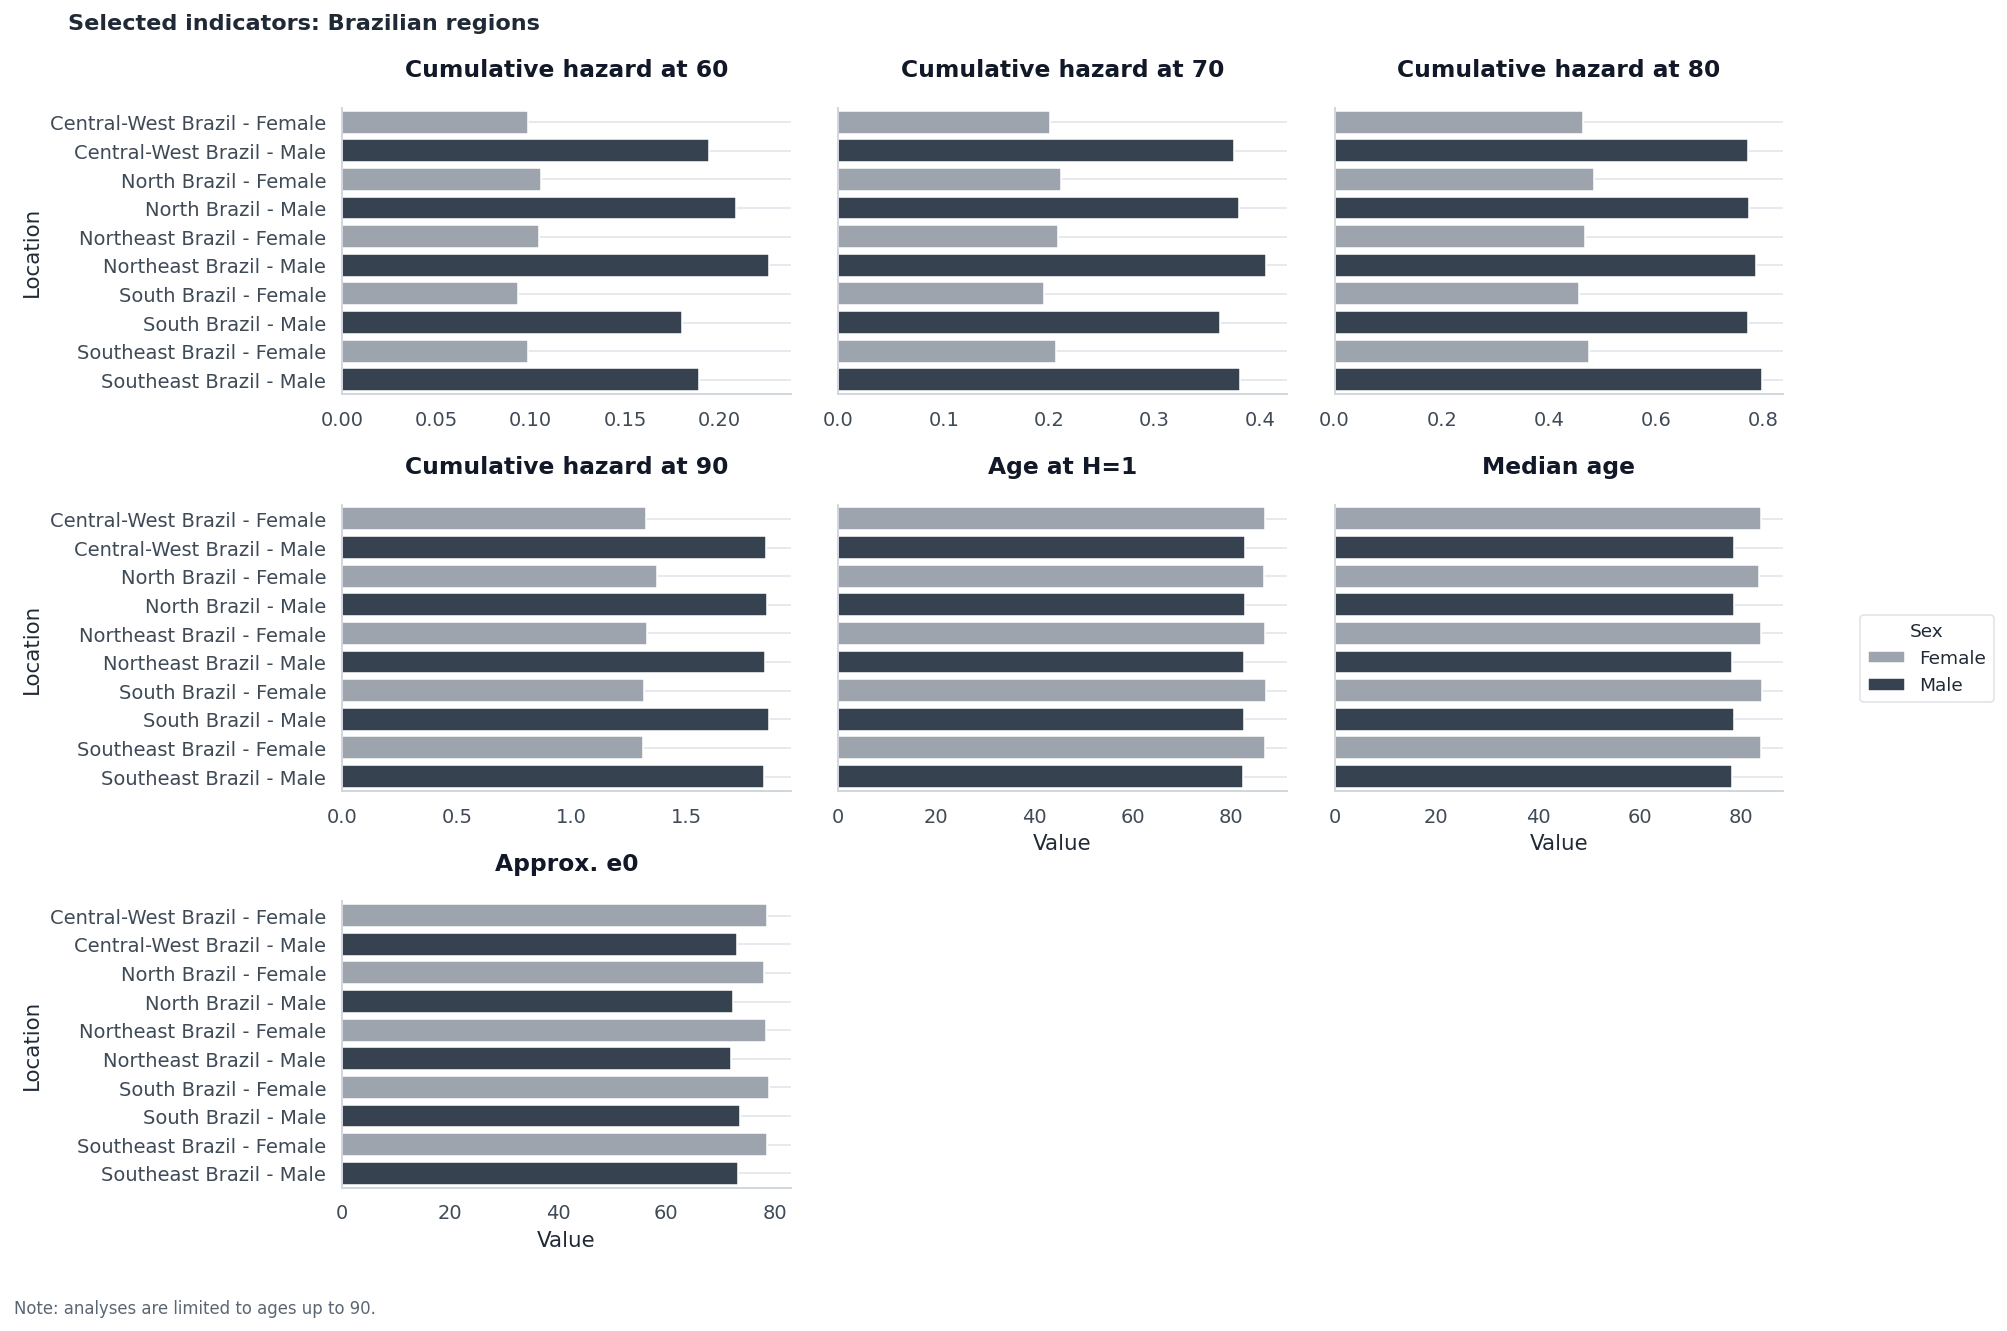

In [6]:
plot_indicator_bars_brazil_regions(
    indicators,
    output_path=PROJECT_ROOT / "outputs" / "figures" / "brazil_regions_indicator_bars.png",
)


## Diferenças por sexo nas regiões brasileiras


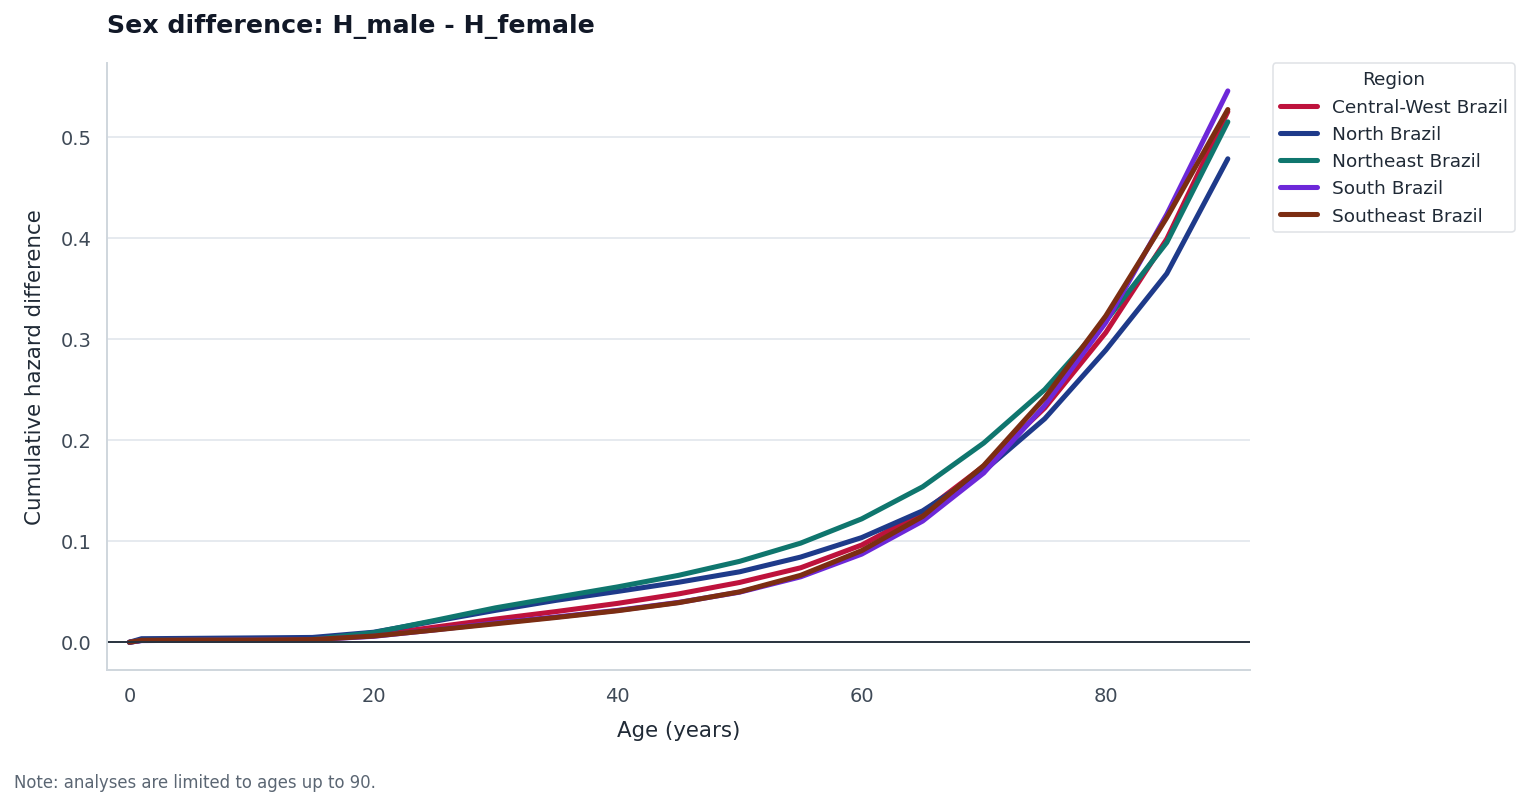

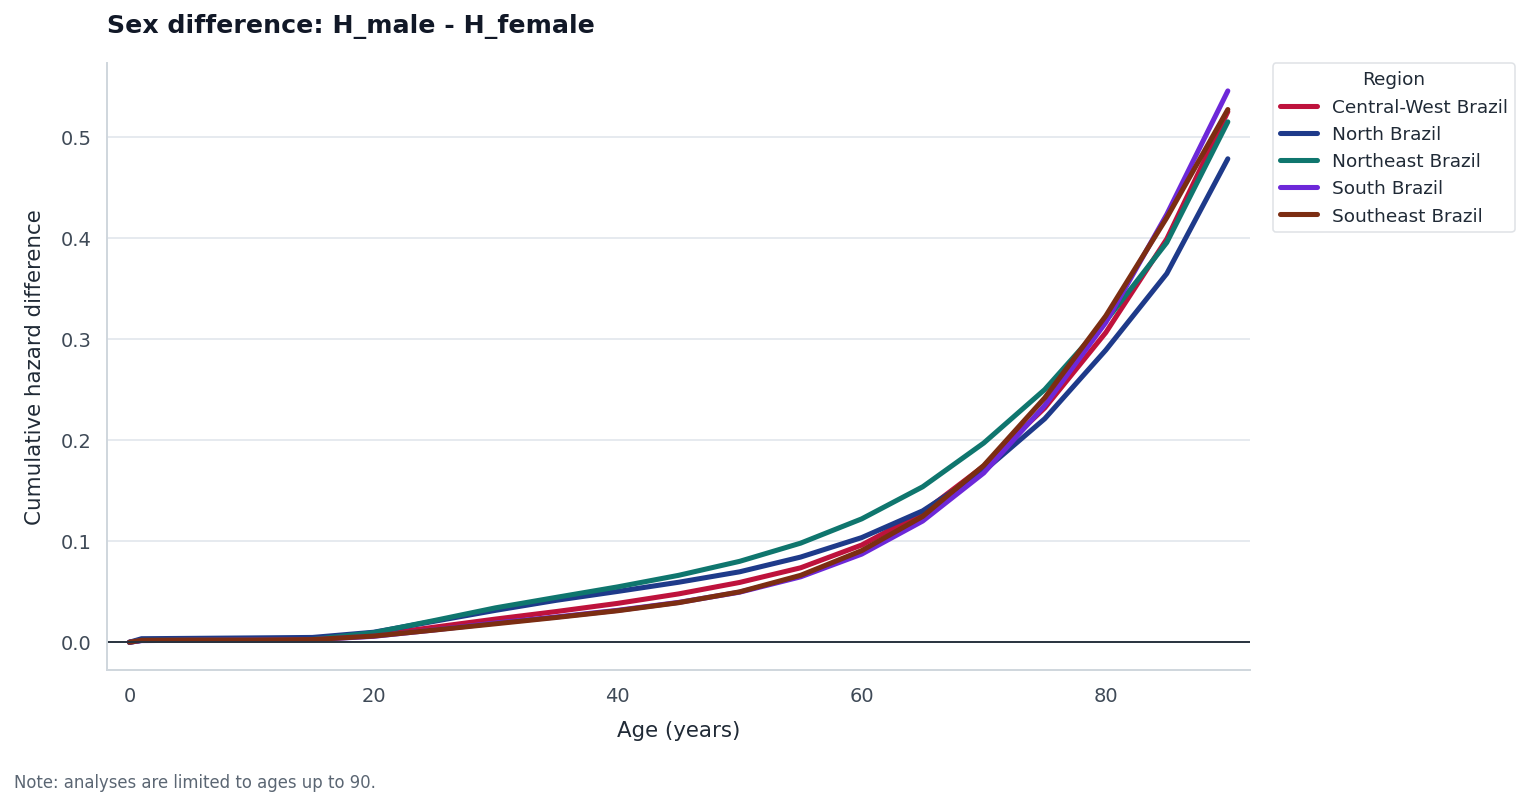

In [7]:
plot_sex_hazard_gap_by_region(
    life_tables,
    output_path=PROJECT_ROOT / "outputs" / "figures" / "sex_hazard_gap_by_region.png",
)


## Chile como referência externa


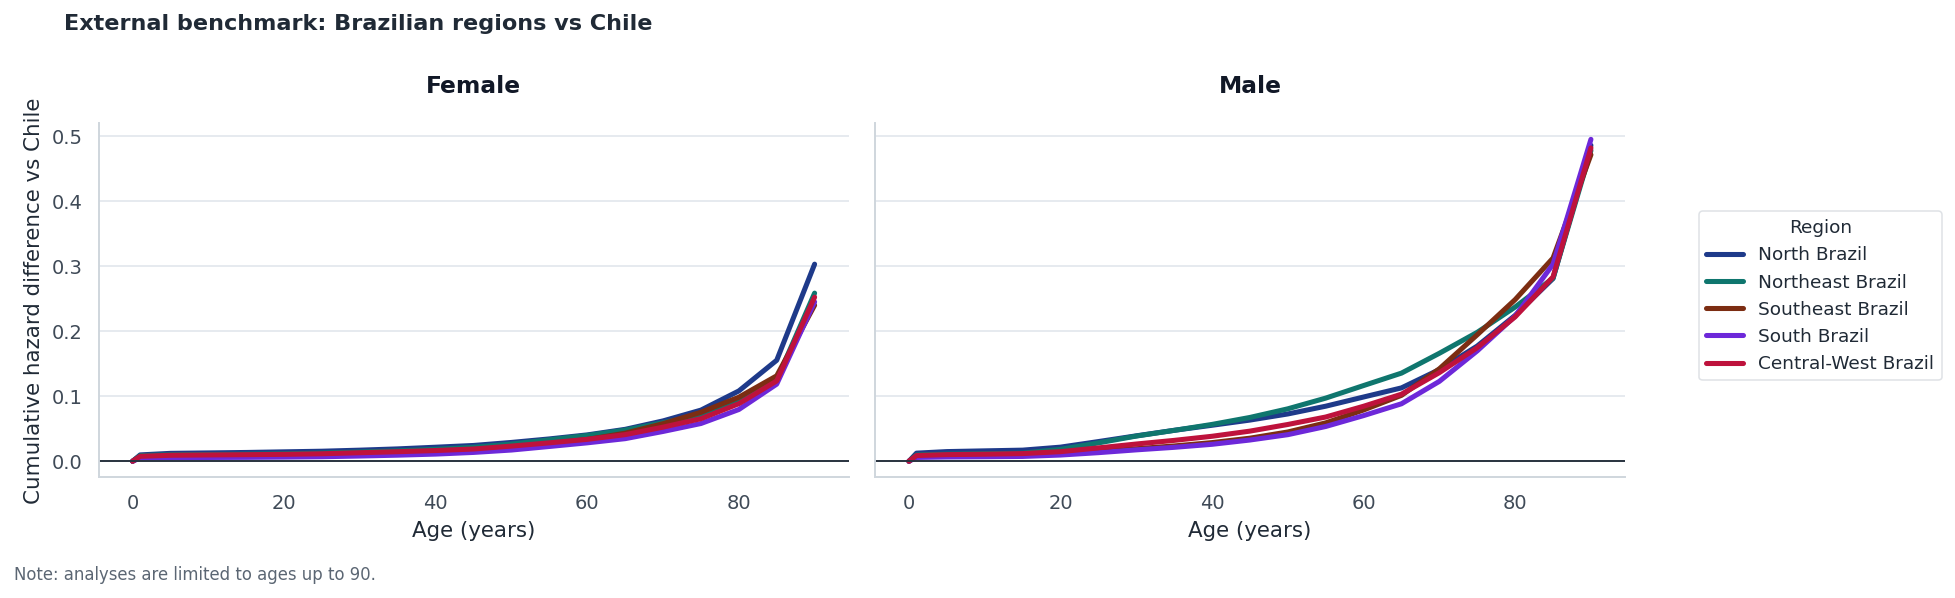

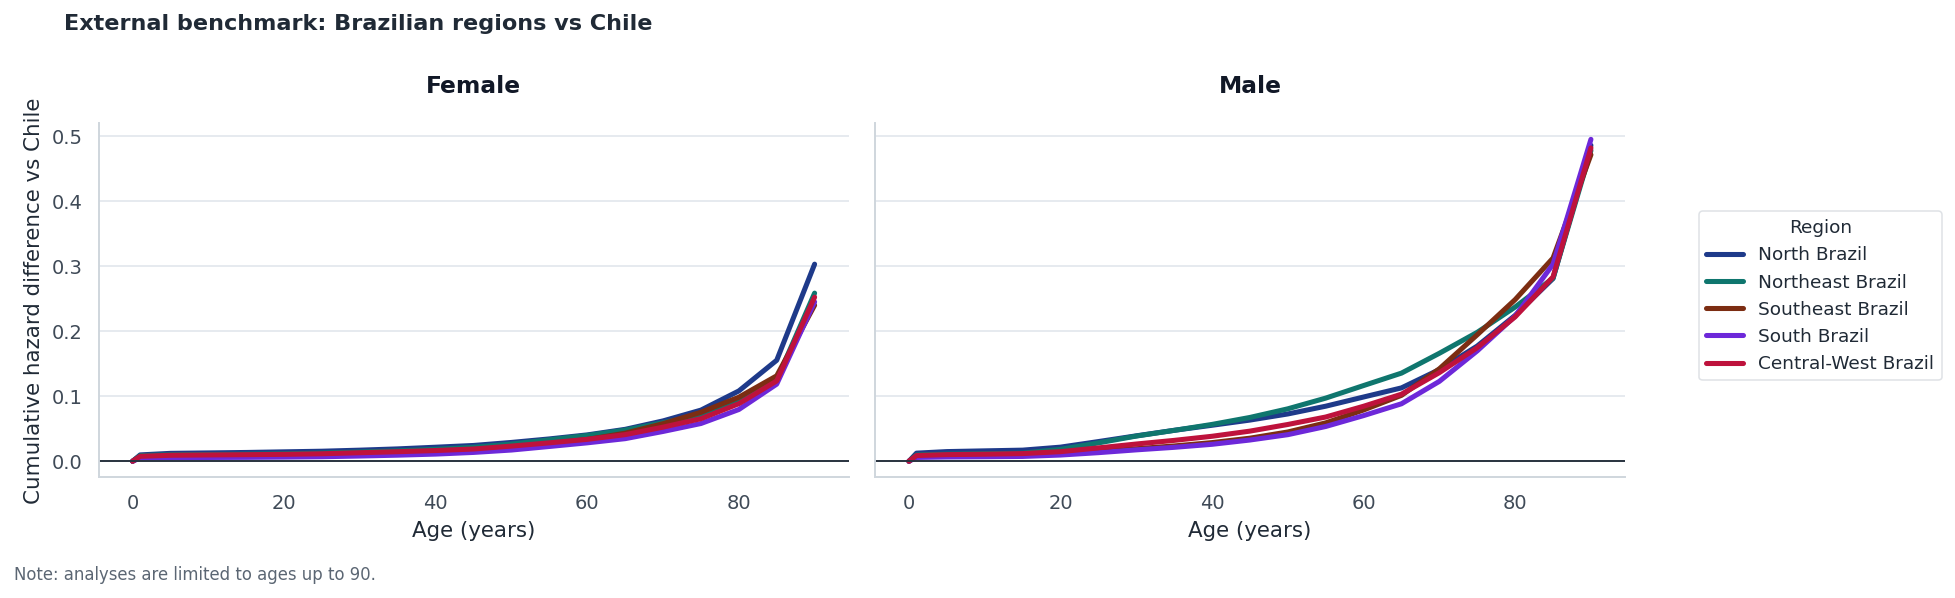

In [8]:
plot_benchmark_hazard_gap_vs_chile(
    life_tables,
    output_path=PROJECT_ROOT / "outputs" / "figures" / "brazil_regions_vs_chile_hazard_gap.png",
)


## Análises complementares

Probabilidades condicionais de sobrevivência, decomposição do risco acumulado por faixa etária e diferenças mulheres-homens nos indicadores sintéticos.


In [9]:
conditional_survival = conditional_survival_probabilities(life_tables)
age_band_contributions = age_band_hazard_contributions(life_tables)
sex_gaps = sex_indicator_gaps(indicators)

conditional_survival


,country,year,start_age,end_age,transition,conditional_survival
0,Central-West Brazil - Female,2025,60,80,60-80,0.693715
1,Central-West Brazil - Female,2025,60,90,60-90,0.293655
2,Central-West Brazil - Female,2025,80,90,80-90,0.423308
3,Central-West Brazil - Male,2025,60,80,60-80,0.562143
4,Central-West Brazil - Male,2025,60,90,60-90,0.191223
5,Central-West Brazil - Male,2025,80,90,80-90,0.340167
6,Chile - Female,2023,60,80,60-80,0.732766
7,Chile - Female,2023,60,90,60-90,0.365319
8,Chile - Female,2023,80,90,80-90,0.498547
9,Chile - Male,2023,60,80,60-80,0.644911


In [10]:
age_band_contributions


,country,year,start_age,end_age,age_band,hazard_increment,share_of_observed_increment
0,Central-West Brazil - Female,2025,0,40,0-40,0.034415,0.025995
1,Central-West Brazil - Female,2025,40,60,40-60,0.064116,0.048430
2,Central-West Brazil - Female,2025,60,80,60-80,0.365694,0.276229
3,Central-West Brazil - Female,2025,80,90,80-90,0.859655,0.649346
4,Central-West Brazil - Male,2025,0,40,0-40,0.072892,0.039421
5,Central-West Brazil - Male,2025,40,60,40-60,0.121869,0.065908
6,Central-West Brazil - Male,2025,60,80,60-80,0.576000,0.311506
7,Central-West Brazil - Male,2025,80,90,80-90,1.078317,0.583165
8,Chile - Female,2023,0,40,0-40,0.018000,0.016792
9,Chile - Female,2023,40,60,40-60,0.046923,0.043775


In [11]:
sex_gaps


,region,year,indicator,female_value,male_value,gap_female_minus_male
0,Central-West Brazil,2025,H_80,0.464224,0.770761,-0.306537
1,Central-West Brazil,2025,H_90,1.323880,1.849079,-0.525199
2,Central-West Brazil,2025,x_H1,87.090024,82.895593,4.194431
3,Central-West Brazil,2025,e0_approx,78.634035,72.991307,5.642729
4,Central-West Brazil,2025,median_age,83.911995,78.541433,5.370562
5,Central-West Brazil,2025,modal_age,87.500000,87.500000,0.000000
6,Chile,2023,H_80,0.375851,0.548971,-0.173120
7,Chile,2023,H_90,1.071908,1.367944,-0.296036
8,Chile,2023,x_H1,89.159684,86.202682,2.957001
9,Chile,2023,e0_approx,81.042863,77.750274,3.292589


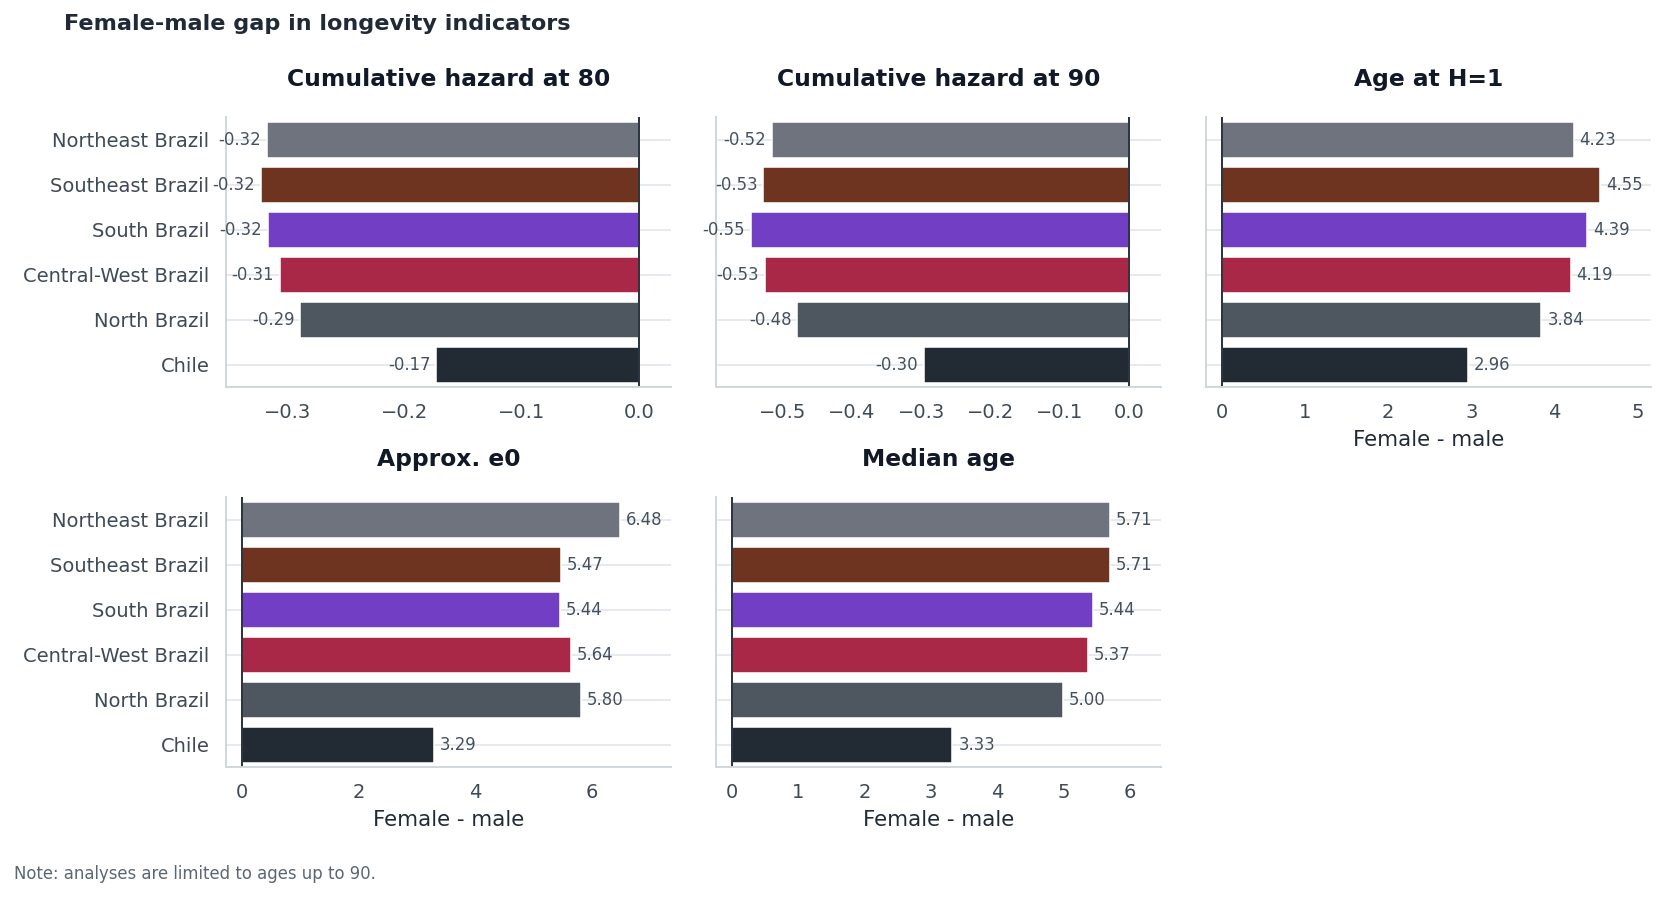

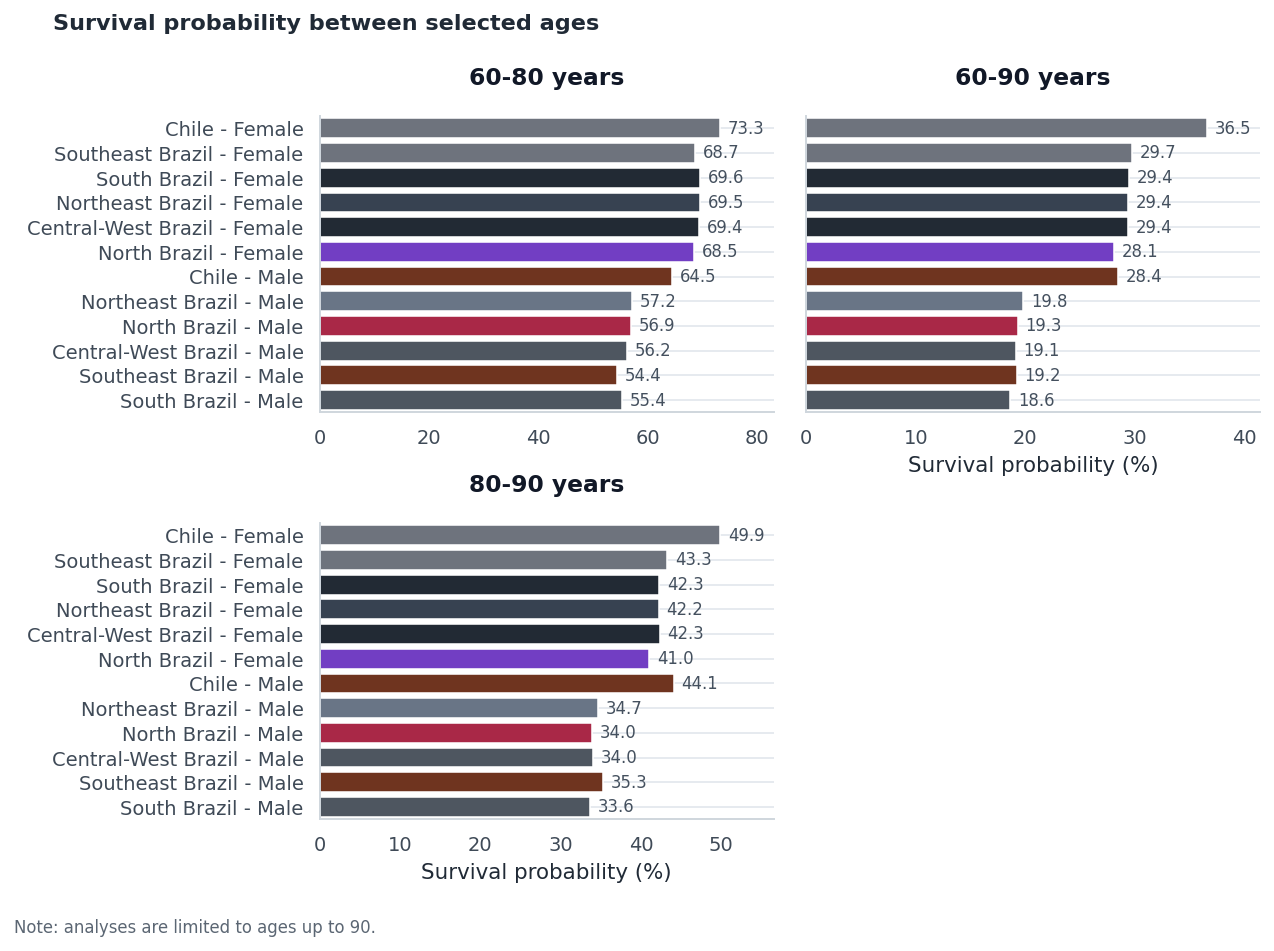

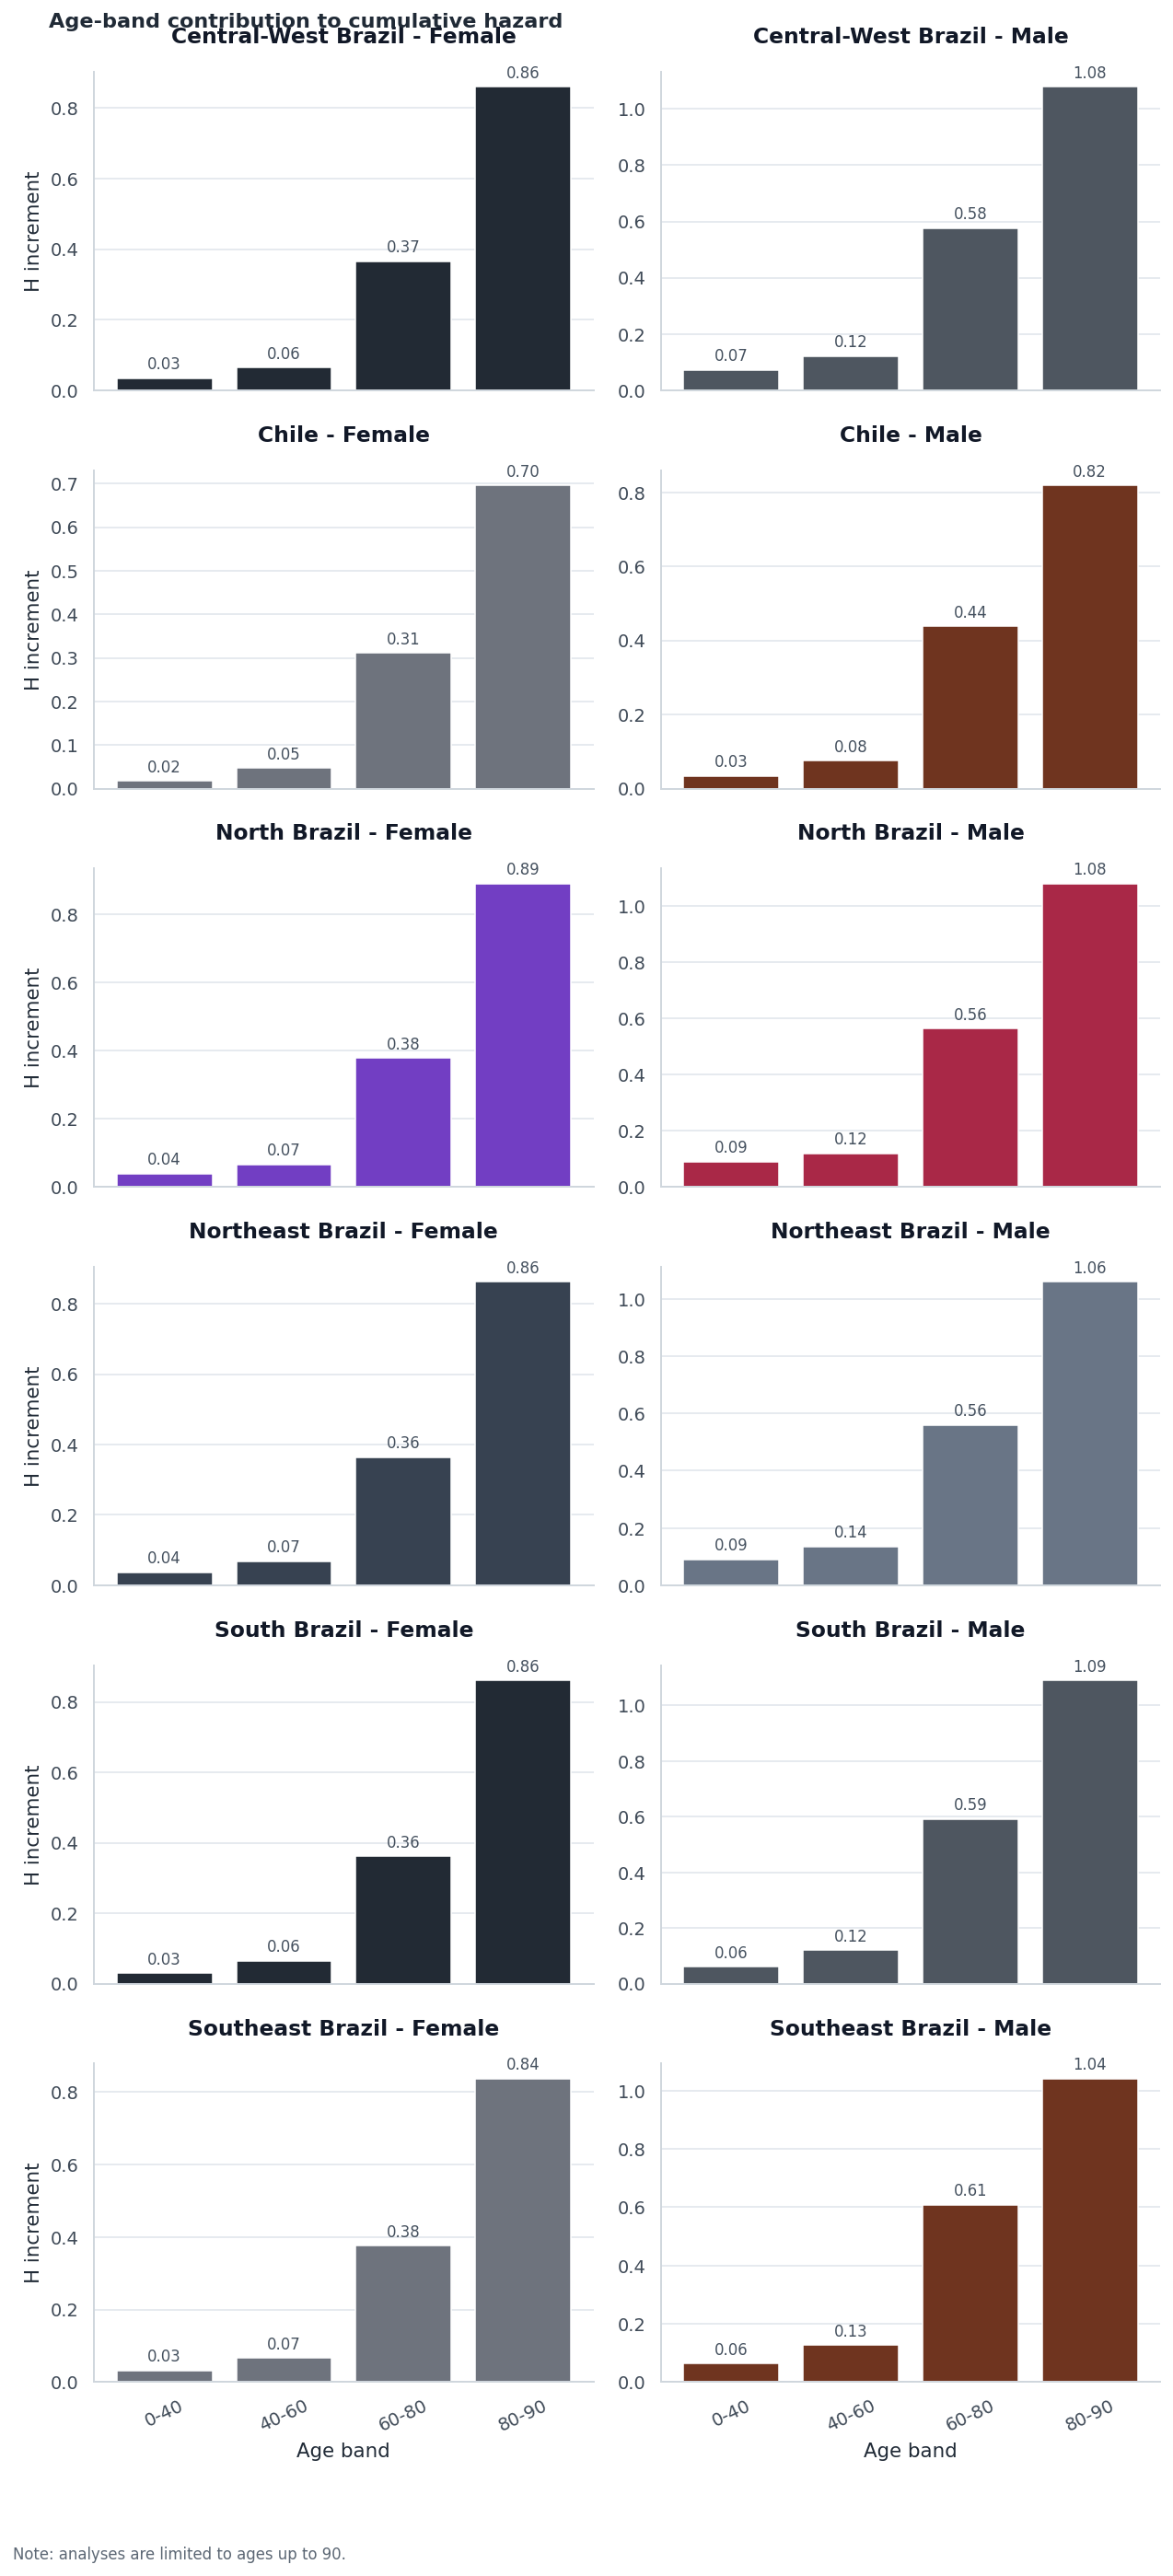

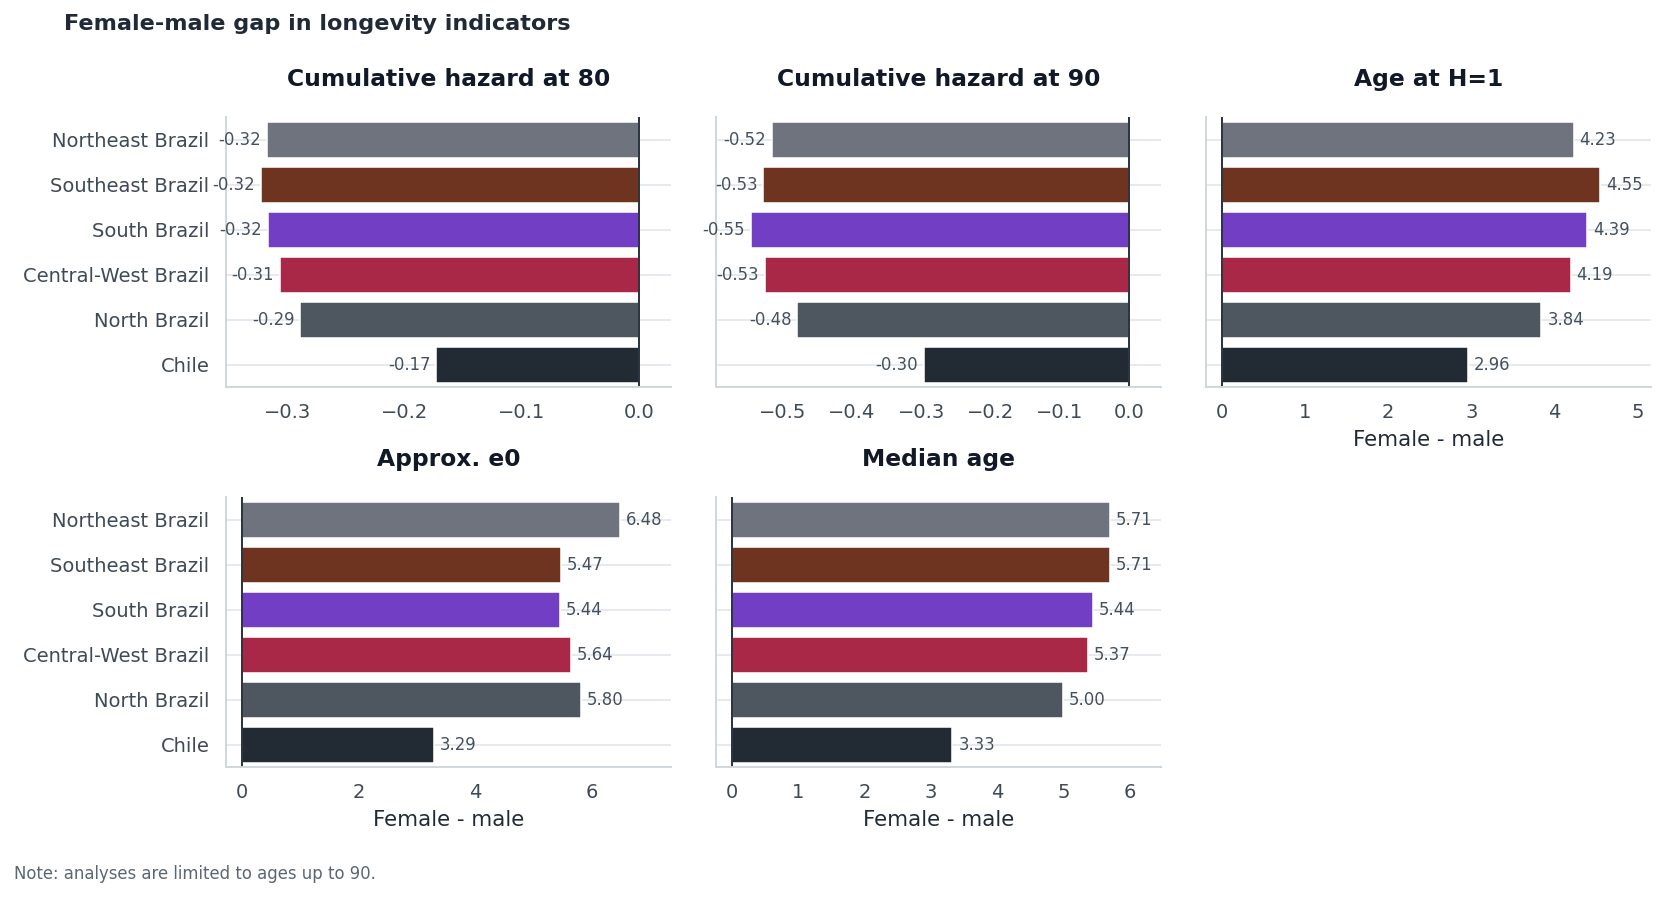

In [12]:
plot_conditional_survival(
    conditional_survival,
    output_path=PROJECT_ROOT / "outputs" / "figures" / "conditional_survival.png",
)
plot_age_band_hazard_contributions(
    age_band_contributions,
    output_path=PROJECT_ROOT / "outputs" / "figures" / "age_band_hazard_contributions.png",
)
plot_sex_indicator_gaps(
    sex_gaps,
    output_path=PROJECT_ROOT / "outputs" / "figures" / "sex_indicator_gaps.png",
)


## Mortalidade masculina entre 20, 40 e 60 anos

Esta seção foca nos homens e compara as regiões brasileiras com o Chile usando probabilidades condicionais de sobrevivência para 20-40, 40-60 e 20-60 anos. A tábua de vida mostra diferenças de mortalidade por idade, mas dados de causa de morte seriam necessários para atribuí-las a causas violentas.


In [13]:
male_life_tables = life_tables[life_tables["country"].str.contains("Male")].copy()

male_20_60_survival = conditional_survival_probabilities(
    male_life_tables,
    transitions=((20, 40), (40, 60), (20, 60)),
)
male_20_60_survival.assign(
    conditional_survival_pct=lambda data: data["conditional_survival"] * 100
).pivot_table(
    index="country",
    columns="transition",
    values="conditional_survival_pct",
).round(2)


transition,20-40,20-60,40-60
country,,,
Central-West Brazil - Male,95.31,84.37,88.53
Chile - Male,97.59,90.47,92.70
North Brazil - Male,94.36,83.76,88.77
Northeast Brazil - Male,93.92,82.02,87.33
South Brazil - Male,95.99,85.15,88.71
Southeast Brazil - Male,95.96,84.61,88.17


In [14]:
male_20_60_hazard = age_band_hazard_contributions(
    male_life_tables,
    bands=((20, 40), (40, 60), (20, 60)),
)
male_20_60_hazard.pivot_table(
    index="country",
    columns="age_band",
    values="hazard_increment",
).round(4)


age_band,20-40,20-60,40-60
country,,,
Central-West Brazil - Male,0.0481,0.1700,0.1219
Chile - Male,0.0244,0.1002,0.0757
North Brazil - Male,0.0581,0.1772,0.1192
Northeast Brazil - Male,0.0627,0.1982,0.1355
South Brazil - Male,0.0409,0.1608,0.1198
Southeast Brazil - Male,0.0413,0.1672,0.1259


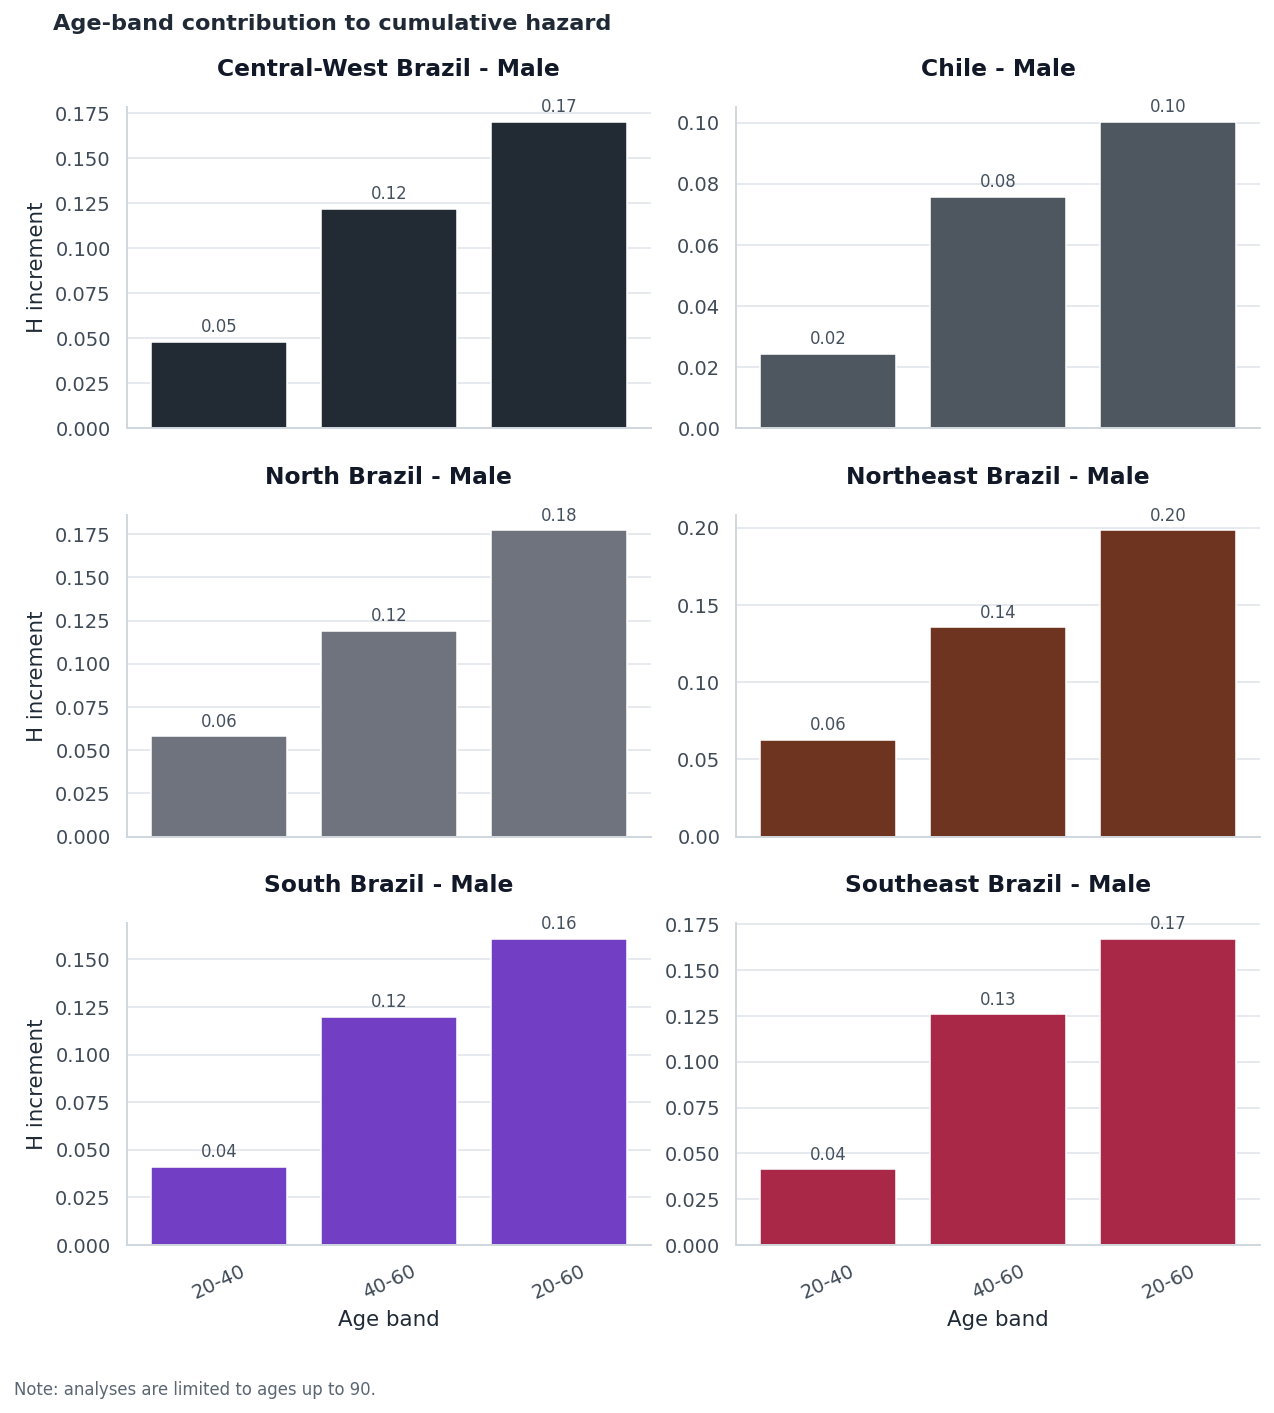

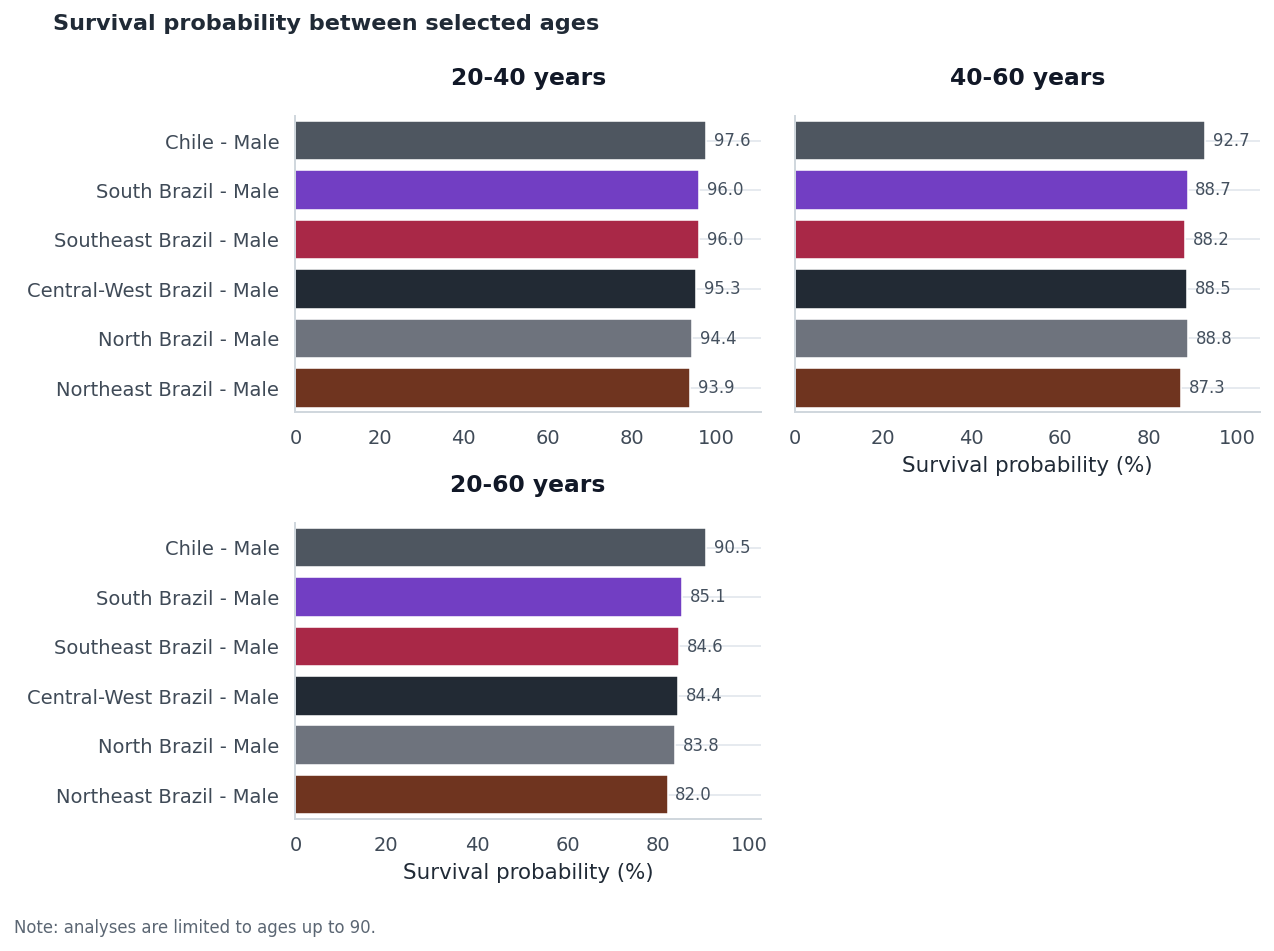

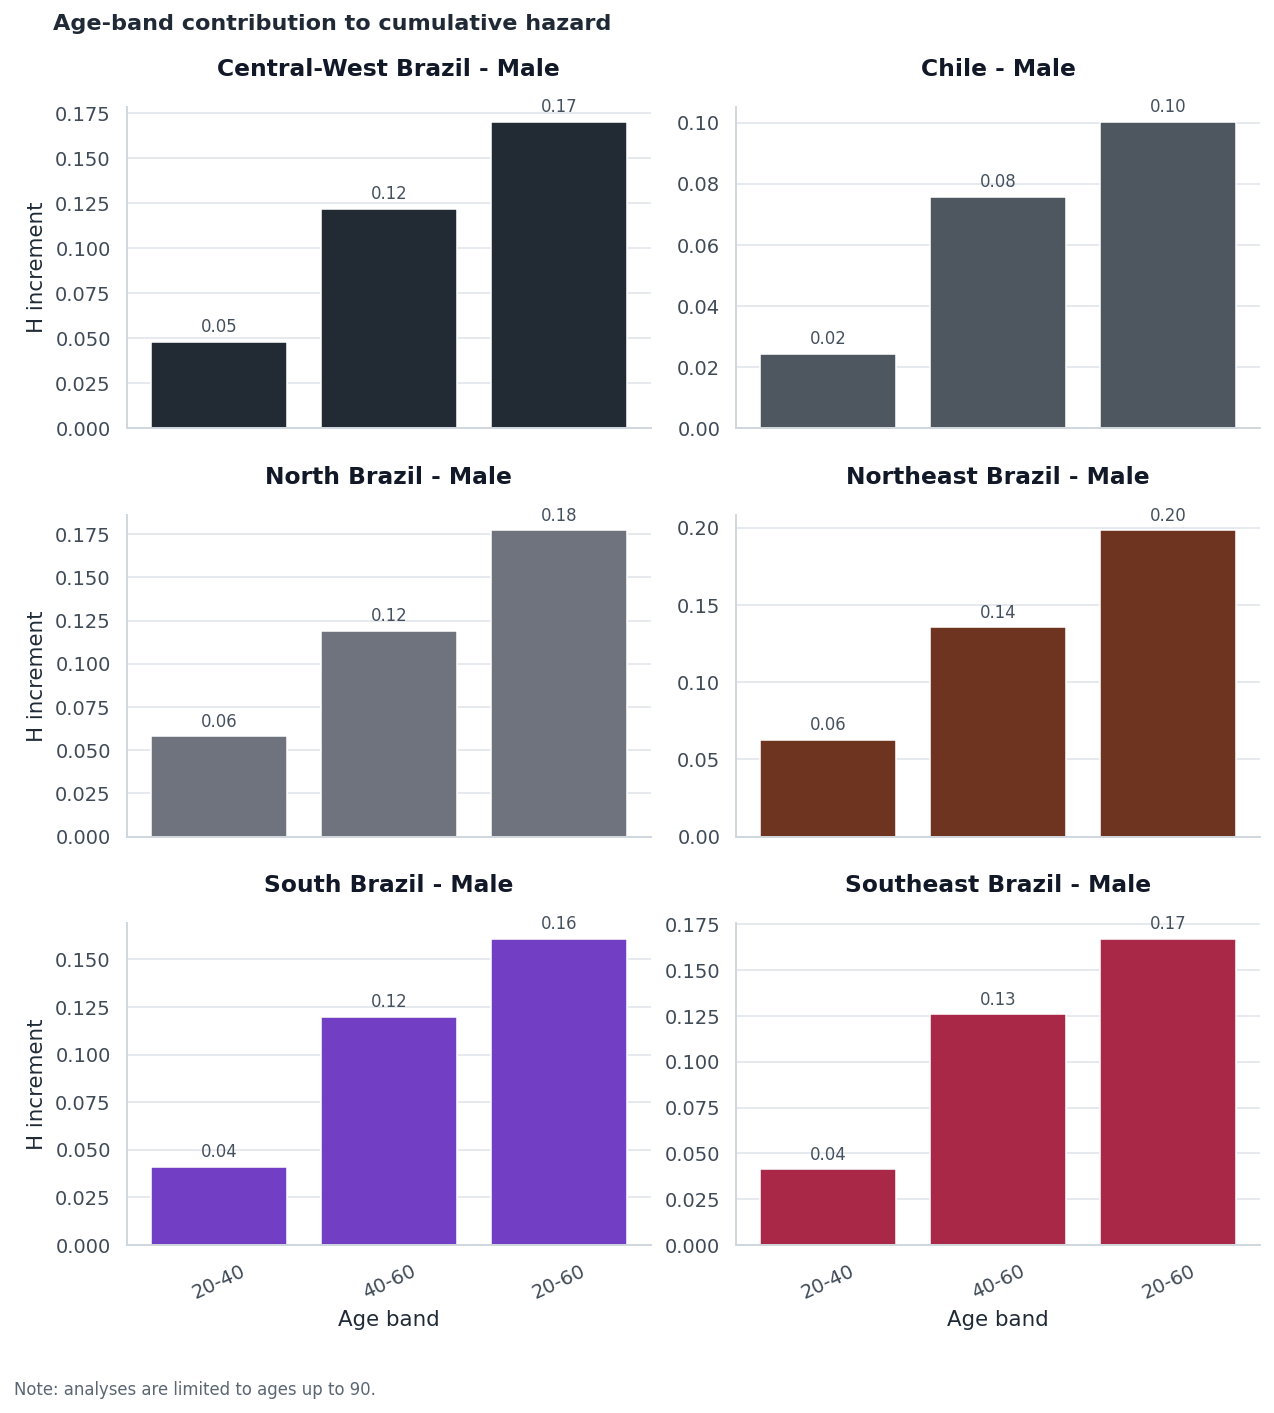

In [15]:
plot_conditional_survival(
    male_20_60_survival,
    output_path=PROJECT_ROOT / "outputs" / "figures" / "male_20_60_conditional_survival.png",
)
plot_age_band_hazard_contributions(
    male_20_60_hazard,
    output_path=PROJECT_ROOT / "outputs" / "figures" / "male_20_60_hazard_contributions.png",
)
